# Multimodality inference playground

Test any-to-any generation with [`gbasi18/Vanilla-10000-Multimodality`](https://huggingface.co/gbasi18/Vanilla-10000-Multimodality).

The published checkpoint was trained with token-choice MoR on CLEVR using **all four modalities in random order**:

```
['tok_rgb@256', 'tok_depth@256', 'tok_normal@256', 'caption']
```

So at inference time it can be conditioned on any subset of those modalities and asked to predict any other one. This notebook loads the model once and then runs each experiment in its own cell so you can tweak inputs without paying the load cost again.

**Sections**

1. Load model (run once)
2. Helpers — chunk builders, `generate(...)`, decoders
3. Reference sample
4. Experiments
   - A — Unconditional generation per modality
   - B — `caption → {rgb, depth, normal}` (text-to-image trio)
   - C — `rgb → {caption, depth, normal}` (image-to-anything)
   - D — Multi-input: `caption + rgb → depth`
   - E — Image prefix completion (inpaint bottom half from RGB top half)
   - F — Sampling temperature sweep
5. Customising experiments


In [7]:
import os

os.environ.setdefault("CUDA_VISIBLE_DEVICES", "0")

from pathlib import Path

PROJECT_DIR = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
os.chdir(PROJECT_DIR)

# DTensor workaround — same as infer.py / pretrain.py (transformers 4.52.4 + single-GPU).
try:
    from torch.distributed.tensor import DTensor
except ImportError:

    class DTensor:
        pass


import transformers.modeling_utils

transformers.modeling_utils.DTensor = DTensor

from util.env import load_dotenv

load_dotenv()

from paths import HF_CACHE_DIR

os.environ.setdefault("HF_HOME", HF_CACHE_DIR)

import json
import numpy as np
import torch
import matplotlib.pyplot as plt

from omegaconf import open_dict
from hydra import initialize_config_dir, compose
from hydra.core.global_hydra import GlobalHydra
from transformers import AutoTokenizer, StoppingCriteria, StoppingCriteriaList

from model.util import load_model_from_config, load_checkpoint
from model.sharing_strategy import SHARING_STRATEGY
from util.config import preprocess_config
from lm_dataset.multimodal_vocab_shared_caption_scene_desc import MODALITIES, PAD_ID
from visualization.decode import _resolve_cosmos_decoder_jit

print("Modalities in vocab:", list(MODALITIES.keys()))
print("PAD_ID:", PAD_ID)

Modalities in vocab: ['tok_rgb@256', 'tok_depth@256', 'tok_normal@256', 'caption', 'scene_desc']
PAD_ID: 242270


### Build the model and load the checkpoint

This composes the inference Hydra config (which inherits from the real training config), assembles the token-choice MoR architecture, and downloads `gbasi18/Vanilla-10000-Multimodality` if it isn't already in `hf_cache/`. It takes ~30 s the first time and a few seconds on rerun.

In [8]:
# initialize_config_dir wants an absolute path. Hydra forbids re-initialising
# in the same process, so clear any previous instance (e.g. from re-running the cell).
if GlobalHydra().is_initialized():
    GlobalHydra().clear()
with initialize_config_dir(config_dir=str(PROJECT_DIR / "conf"), version_base=None):
    cfg = compose(config_name="infer/vanilla_10000_multimodality")

with open_dict(cfg):
    cfg.wandb = False
    cfg.wandb_entity = ""
    cfg.wandb_project = "inference"
    cfg.wandb_run_name = "inference"
    cfg.resume_from_checkpoint = False
cfg = preprocess_config(cfg)

DEVICE = cfg.infer.device if torch.cuda.is_available() else "cpu"
print(f"Building model on {DEVICE}…")

model = load_model_from_config(cfg)
if cfg.recursive.get("enable"):
    model, _ = SHARING_STRATEGY[cfg.model](cfg, model)
if "kv_sharing" in cfg and cfg.kv_sharing.get("enable"):
    model.set_kv_sharing_config(cfg)
if "mor" in cfg and cfg.mor.get("enable"):
    if cfg.mor.type == "expert":
        model.transform_layer_to_mor_expert(cfg)
    elif cfg.mor.type == "token":
        model.transform_layer_to_mor_token(cfg)

print(f"Loading checkpoint: {cfg.infer.checkpoint}")
model = load_checkpoint(model, cfg.infer.checkpoint)
model.to(DEVICE).eval()

print(
    "Ready. layers =",
    model.config.num_hidden_layers,
    " vocab =",
    model.config.vocab_size,
    " max_pos =",
    model.config.max_position_embeddings,
)

-------------------------------Preprocess Config -------------------------------
Automatically determining batch size based on `total_batch_size`
total_batch_size              : 256 (given)
torch.cuda.device_count()     : 1
per_device_train_batch_size   : 8 (given)
gradient_accumulation_steps   : 32 (computed)
actual total batch size       : 256
Setting output_dir  : vanilla_10000_multimodality_infer
Using deepspeed config = /home/hugues/Documents/Visual_Intelligence/Mixture-of-Recursions-for-Vision/ds_configs/stage2.config
--------------------------------------------------------------------------------
Building model on cuda…
Initializing model from scratch...
Using custom config for vanilla model...
 num_hidden_layers: 29
 vocab_size: 242271


/home/hugues/Documents/Visual_Intelligence/Mixture-of-Recursions-for-Vision/model/util.py:90: UserWarning: original max_position_embeddings of 2048 is changed to 1024
  warnings.warn(f"original max_position_embeddings of {config.max_position_embeddings} is changed to {cfg.max_length}")


Loading checkpoint: gbasi18/Vanilla-10000-Multimodality


Fetching 5 files: 100%|██████████| 5/5 [00:00<00:00, 33026.02it/s]


  Cached at: /home/hugues/.cache/huggingface/hub/models--gbasi18--Vanilla-10000-Multimodality/snapshots/eb012116babe2199144d4815453389a07da4aaa0
Ready. layers = 29  vocab = 242271  max_pos = 1024


## 2. Helpers — building prompts, generating, decoding

Each modality contributes a chunk shaped `<BO_mod> body_tokens <EO_mod>`. Token modalities (`tok_rgb@256`, `tok_depth@256`, `tok_normal@256`) carry 256 Cosmos VQ indices; text modalities (`caption`, `scene_desc`) carry GPT-2 ids. All ids are shifted into the unified vocab by `MODALITIES[name].codebook_offset`.

To run an inference experiment you build a list of *input* chunks (any subset / any order) and pick a *target* modality. We append `<BO_target>` and let the model fill in body tokens until it emits `<EO_target>`.

The Cosmos image decoder is cached after the first call to keep cells fast.

In [9]:
PATCH_GRID = cfg.infer.patch_grid_size  # 16 -> 16x16=256 image tokens
COSMOS_PATH = cfg.infer.cosmos_model_path
TEXT_MAX_LEN = cfg.multimodal.get("text_max_length", 64)
GPT2_TOK = AutoTokenizer.from_pretrained("gpt2")

# ------------------------- Cosmos decoder cache -------------------------
_cosmos_decoder = None


def _get_cosmos_decoder():
    """ImageTokenizer is expensive to build; cache one instance for the whole notebook."""
    global _cosmos_decoder
    if _cosmos_decoder is None:
        from cosmos_tokenizer.image_lib import ImageTokenizer

        decoder_jit = _resolve_cosmos_decoder_jit(COSMOS_PATH)
        _cosmos_decoder = ImageTokenizer(
            checkpoint_dec=decoder_jit, device="cuda", dtype="bfloat16"
        )
    return _cosmos_decoder


def decode_image_tokens(raw_tokens: np.ndarray) -> np.ndarray | None:
    """raw_tokens: (256,) int VQ indices in [0, 64000) -> HxWx3 uint8 image, or None."""
    if raw_tokens.size != PATCH_GRID * PATCH_GRID:
        print(f"  [warn] need {PATCH_GRID**2} tokens, got {raw_tokens.size}")
        return None
    if not (DEVICE == "cuda" and torch.cuda.is_available()):
        print("  [warn] Cosmos decode requires CUDA.")
        return None
    tokenizer = _get_cosmos_decoder()
    indices = (
        torch.from_numpy(raw_tokens.astype(np.int64)).reshape(1, PATCH_GRID, PATCH_GRID).to("cuda")
    )
    with torch.no_grad():
        decoded = tokenizer.decode(indices).float().cpu().numpy()[0]  # (3, H, W) in ~[-1, 1]
    decoded = np.clip((decoded + 1.0) / 2.0, 0.0, 1.0)
    return (decoded.transpose(1, 2, 0) * 255.0 + 0.5).astype(np.uint8)


# ------------------------- Chunk builders -------------------------
def chunk_text(modality: str, text: str, *, close: bool = True) -> torch.Tensor:
    """<BO_mod> + GPT-2(text) + <EO_mod> (or no EO if close=False)."""
    info = MODALITIES[modality]
    assert info.data_type == "text", f"{modality} is not a text modality"
    ids = GPT2_TOK(text, truncation=True, max_length=TEXT_MAX_LEN, return_tensors="pt")[
        "input_ids"
    ][0].long()
    parts = [torch.tensor([info.bo_id]), ids + info.codebook_offset]
    if close:
        parts.append(torch.tensor([info.eo_id]))
    return torch.cat(parts)


def chunk_tokens(
    modality: str, source, *, aug_idx: int = 0, prefix_len: int | None = None, close: bool = True
) -> torch.Tensor:
    """source can be a path to a (K,N) .npy or a 1D array of raw codebook indices."""
    info = MODALITIES[modality]
    assert info.data_type == "tokens", f"{modality} is not a tokens modality"
    arr = np.load(source) if isinstance(source, (str, Path)) else np.asarray(source)
    if arr.ndim == 2:
        arr = arr[aug_idx]
    body = torch.from_numpy(arr.flatten()).long() + info.codebook_offset
    if prefix_len is not None:
        body = body[:prefix_len]
        close = False  # prefix mode: no EO; the model continues the same modality
    parts = [torch.tensor([info.bo_id]), body]
    if close:
        parts.append(torch.tensor([info.eo_id]))
    return torch.cat(parts)


# ------------------------- Generation -------------------------
class _EoModStopping(StoppingCriteria):
    def __init__(self, eo_id):
        self.eo_id = eo_id

    def __call__(self, input_ids, scores, **kwargs):
        return bool((input_ids[:, -1] == self.eo_id).all())


def generate(
    chunks: list[torch.Tensor],
    target_modality: str | None = None,
    *,
    continue_modality: str | None = None,
    max_new_tokens: int | None = None,
    do_sample: bool = False,
    temperature: float = 1.0,
    top_k: int = 0,
    top_p: float = 1.0,
    seed: int | None = None,
    use_cache: bool | None = None,
) -> torch.Tensor:
    """Generate body tokens conditioned on `chunks`.

    Two modes:
      - target_modality='X' (default): the prompt is `chunks + <BO_X>` and we stop at <EO_X>.
      - continue_modality='X': the last chunk must have been built with close=False, so the
        prompt already ends inside an open X-chunk; we just stop at <EO_X>.
        Used for prefix-completion (e.g. fill in the bottom half of an image).
    """
    if (target_modality is None) == (continue_modality is None):
        raise ValueError("pass exactly one of target_modality / continue_modality")

    if target_modality is not None:
        info = MODALITIES[target_modality]
        prompt = torch.cat([*chunks, torch.tensor([info.bo_id])]).unsqueeze(0)
    else:
        info = MODALITIES[continue_modality]
        prompt = torch.cat(chunks).unsqueeze(0)

    if max_new_tokens is None:
        max_new_tokens = 257 if info.data_type == "tokens" else (TEXT_MAX_LEN + 1)
    if use_cache is None:
        use_cache = bool(cfg.infer.use_cache)
    if seed is not None:
        torch.manual_seed(seed)

    do_sample_eff = do_sample or temperature != 1.0 or top_k != 0 or top_p != 1.0
    prompt = prompt.to(DEVICE)
    with torch.no_grad():
        out = model.generate(
            input_ids=prompt,
            attention_mask=torch.ones_like(prompt),
            max_new_tokens=max_new_tokens,
            use_cache=use_cache,
            stopping_criteria=StoppingCriteriaList([_EoModStopping(info.eo_id)]),
            do_sample=do_sample_eff,
            temperature=temperature if do_sample_eff else 1.0,
            top_k=top_k if do_sample_eff else 0,
            top_p=top_p if do_sample_eff else 1.0,
            pad_token_id=PAD_ID,
        )
    return out[0, prompt.shape[1] :].cpu()


# ------------------------- Display -------------------------
def _strip_specials(tokens: torch.Tensor, info) -> np.ndarray:
    body = tokens[(tokens != info.bo_id) & (tokens != info.eo_id) & (tokens != PAD_ID)]
    return (body - info.codebook_offset).cpu().numpy()


def show_text(tokens: torch.Tensor, modality: str) -> str:
    raw = _strip_specials(tokens, MODALITIES[modality]).tolist()
    text = GPT2_TOK.decode(raw, skip_special_tokens=True)
    print(f"[{modality}] {text}")
    return text


def show_image(
    tokens_or_array,
    modality: str,
    *,
    ax=None,
    title: str | None = None,
    extra_prefix: np.ndarray | None = None,
):
    """Decode either a 1D array of raw VQ indices or a Tensor of generated unified-vocab tokens."""
    if isinstance(tokens_or_array, torch.Tensor):
        raw = _strip_specials(tokens_or_array, MODALITIES[modality])
    else:
        raw = np.asarray(tokens_or_array).flatten()
    if extra_prefix is not None:
        raw = np.concatenate([np.asarray(extra_prefix).flatten(), raw])
    img = decode_image_tokens(raw[: PATCH_GRID * PATCH_GRID])
    if img is None:
        return None
    if ax is None:
        _, ax = plt.subplots(figsize=(3, 3))
    ax.imshow(img)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title(title or modality, fontsize=9)
    return img


def show(tokens: torch.Tensor, modality: str, **kwargs):
    """Auto-dispatch: text -> show_text, image tokens -> show_image."""
    if MODALITIES[modality].data_type == "tokens":
        return show_image(tokens, modality, **kwargs)
    return show_text(tokens, modality)


print("helpers ready.")

helpers ready.


## 3. Reference sample

Look at one CLEVR test sample (id `00000`) so we have a known ground truth to compare against. Each `.npy` has shape `(K, N)` where `K=10` is the number of caption / view augmentations and `N=256` is the image-token length; `.json` files hold the `K` caption strings.

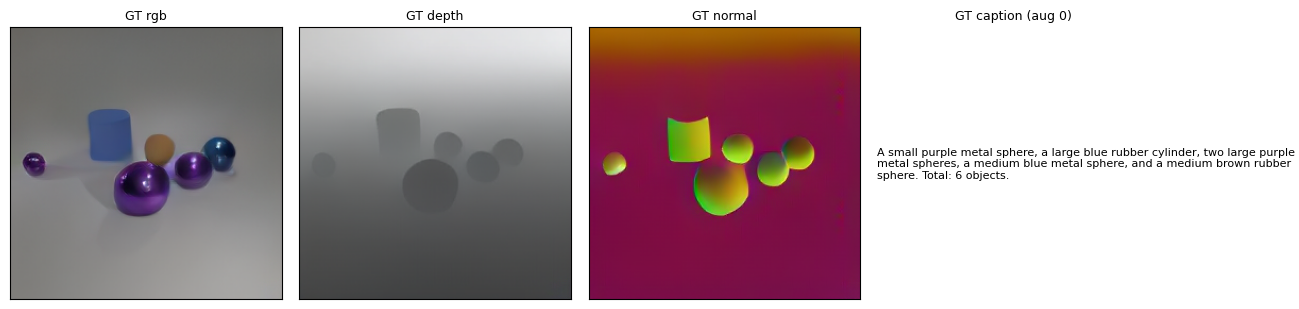

In [10]:
SAMPLE_ID = "00000"  # change to any 5-digit id under data/clevr_dataset/test/
AUG_IDX = 0  # which of the K augmentations to use as ground truth
DATA_TEST = Path("data/clevr_dataset/test")

ref_rgb = np.load(DATA_TEST / "tok_rgb@256" / f"{SAMPLE_ID}.npy")[AUG_IDX]
ref_depth = np.load(DATA_TEST / "tok_depth@256" / f"{SAMPLE_ID}.npy")[AUG_IDX]
ref_normal = np.load(DATA_TEST / "tok_normal@256" / f"{SAMPLE_ID}.npy")[AUG_IDX]
with open(DATA_TEST / "caption" / f"{SAMPLE_ID}.json") as f:
    ref_captions = json.load(f)

fig, axes = plt.subplots(1, 4, figsize=(13, 3.2))
show_image(ref_rgb, "tok_rgb@256", ax=axes[0], title="GT rgb")
show_image(ref_depth, "tok_depth@256", ax=axes[1], title="GT depth")
show_image(ref_normal, "tok_normal@256", ax=axes[2], title="GT normal")
axes[3].axis("off")
axes[3].set_title("GT caption (aug 0)", fontsize=9)
axes[3].text(0.0, 0.5, ref_captions[AUG_IDX], wrap=True, fontsize=8, va="center")
plt.tight_layout()
plt.show()

## 4. Experiments

### A — Unconditional generation per modality

No conditioning chunks. `<BO_target>` is the entire prompt; the model emits a full body and then `<EO_target>`. Sampling is on (greedy unconditional generation collapses to the same image every time).

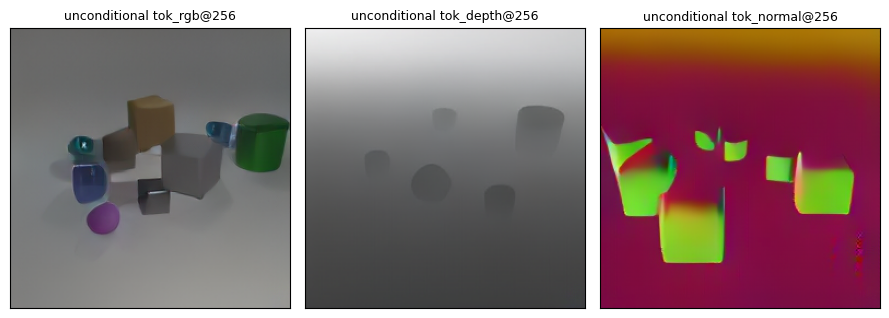


Unconditional captions:
[caption] In this image, you can see a yellow metal cylinder, a green rubber cube, and a small brown rubber cylinder; total of 3 objects.
[caption] In the image, you can see one medium blue cylinder made of metal.
[caption] This image features three items—a large blue cylindrical metal piece, a medium-sized red cylindrical metal object, and a medium-sized brown spherical metal item.


In [11]:
image_targets = ["tok_rgb@256", "tok_depth@256", "tok_normal@256"]

fig, axes = plt.subplots(1, len(image_targets), figsize=(3 * len(image_targets), 3.2))
for ax, target in zip(axes, image_targets):
    out = generate([], target_modality=target, do_sample=True, temperature=0.9, seed=0)
    show_image(out, target, ax=ax, title=f"unconditional {target}")
plt.tight_layout()
plt.show()

print("\nUnconditional captions:")
for seed in [0, 1, 2]:
    out = generate([], target_modality="caption", do_sample=True, temperature=0.9, seed=seed)
    show_text(out, "caption")

### B — `caption → {rgb, depth, normal}` (text-to-image trio)

One caption, three target image modalities. The same caption produces three views of the same scene in the model's "imagination": RGB, depth and surface normals.

The following generation flags are not valid and may be ignored: ['top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
The following generation flags are not valid and may be ignored: ['top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
The following generation flags are not valid and may be ignored: ['top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


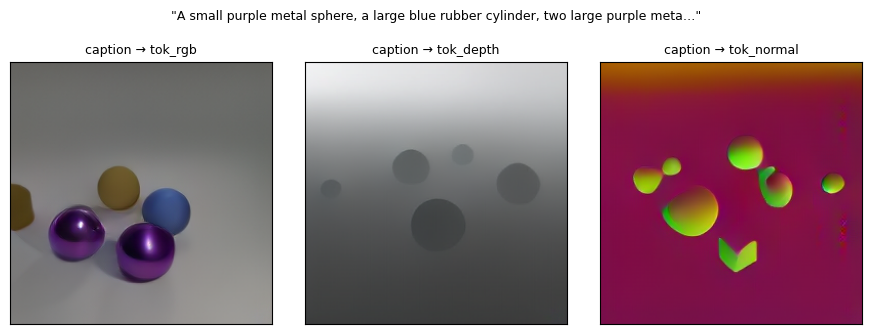

In [12]:
caption = ref_captions[AUG_IDX]  # try a custom string here
chunks = [chunk_text("caption", caption)]

fig, axes = plt.subplots(1, len(image_targets), figsize=(3 * len(image_targets), 3.2))
for ax, target in zip(axes, image_targets):
    out = generate(chunks, target_modality=target, seed=0)  # greedy
    show_image(out, target, ax=ax, title=f"caption → {target.split('@')[0]}")
plt.suptitle(f'"{caption[:80]}{"…" if len(caption) > 80 else ""}"', fontsize=9, y=1.03)
plt.tight_layout()
plt.show()

### C — `rgb → {caption, depth, normal}`

Condition on the ground-truth RGB tokens for `SAMPLE_ID` and ask the model to predict each of the other modalities. Captions are sampled (greedy captions are very repetitive); image targets stay greedy.

--- tok_rgb@256 → caption (3 sampled captions) ---
[caption] In this image, you can see six objects: a large blue rubber cylinder, a medium blue metal sphere, a medium brown rubber sphere, a large purple metal sphere, a small purple metal sphere, and a medium purple metal sphere.
[caption] Six objects are present: a large purple metal sphere, a medium blue metal sphere, a small purple metal sphere, a medium brown rubber sphere, a medium purple metal sphere, and a large blue rubber cylinder.


The following generation flags are not valid and may be ignored: ['top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


[caption] This image features six objects: a large blue rubber cylinder, a large purple metal sphere, a medium blue metal sphere, a medium brown rubber sphere, a small metal sphere, and a medium purple metal sphere.

--- tok_rgb@256 → tok_depth / tok_normal (greedy) ---


The following generation flags are not valid and may be ignored: ['top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


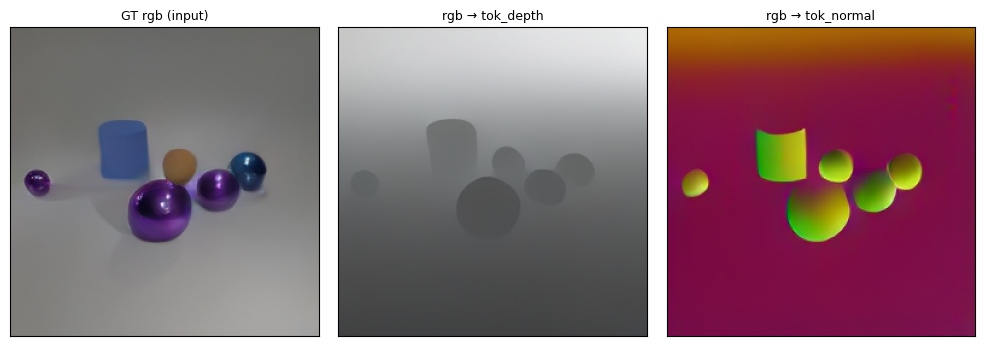

In [13]:
chunks_rgb = [chunk_tokens("tok_rgb@256", ref_rgb)]  # numpy array works directly

print("--- tok_rgb@256 → caption (3 sampled captions) ---")
for seed in [0, 1, 2]:
    out = generate(
        chunks_rgb, target_modality="caption", do_sample=True, temperature=0.7, seed=seed
    )
    show_text(out, "caption")

print("\n--- tok_rgb@256 → tok_depth / tok_normal (greedy) ---")
fig, axes = plt.subplots(1, 3, figsize=(10, 3.4))
show_image(ref_rgb, "tok_rgb@256", ax=axes[0], title="GT rgb (input)")
for ax, target in zip(axes[1:], ["tok_depth@256", "tok_normal@256"]):
    out = generate(chunks_rgb, target_modality=target, seed=0)
    show_image(out, target, ax=ax, title=f"rgb → {target.split('@')[0]}")
plt.tight_layout()
plt.show()

### D — Multi-input: `caption + rgb → depth`

Stack chunks to condition on more than one modality at once. Because training used `modality_order=random`, swapping the order of `caption` and `tok_rgb@256` chunks should give comparable results — change them around to verify.

The following generation flags are not valid and may be ignored: ['top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


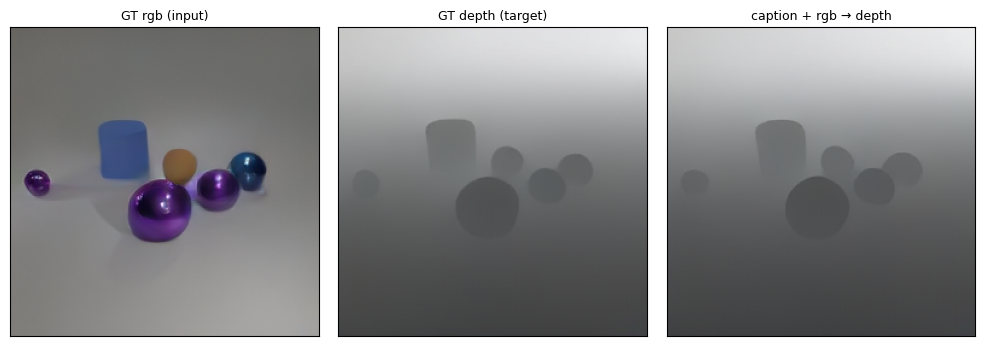

In [14]:
chunks_multi = [
    chunk_text("caption", ref_captions[AUG_IDX]),
    chunk_tokens("tok_rgb@256", ref_rgb),
]

fig, axes = plt.subplots(1, 3, figsize=(10, 3.4))
show_image(ref_rgb, "tok_rgb@256", ax=axes[0], title="GT rgb (input)")
show_image(ref_depth, "tok_depth@256", ax=axes[1], title="GT depth (target)")
out = generate(chunks_multi, target_modality="tok_depth@256", seed=0)
show_image(out, "tok_depth@256", ax=axes[2], title="caption + rgb → depth")
plt.tight_layout()
plt.show()

### E — Image prefix completion (inpaint bottom half)

Feed `<BO_rgb>` + the first 128 RGB tokens (top half of the 16x16 grid) and let the model autoregressively fill the remaining 128 tokens until it emits `<EO_rgb>`. We then concatenate prefix + continuation and decode the full 256-token image. Useful for inpainting / outpainting and for sanity-checking that the model learnt local image priors.

The following generation flags are not valid and may be ignored: ['top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


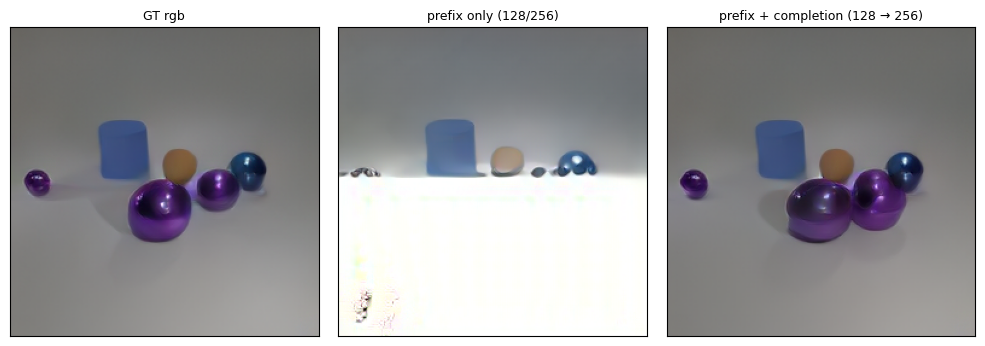

In [15]:
PREFIX_LEN = 128  # 8 of 16 rows (top half)
prefix_arr = ref_rgb[:PREFIX_LEN]  # raw codebook indices in [0, 64000)

# Note: chunk_tokens(prefix_len=...) sets close=False, so the chunk ends inside
# an open <BO_rgb> ... block. We then call generate(continue_modality='tok_rgb@256')
# which does NOT append another <BO_rgb> — it just lets the model continue.
chunks_prefix = [chunk_tokens("tok_rgb@256", ref_rgb, prefix_len=PREFIX_LEN)]
out = generate(chunks_prefix, continue_modality="tok_rgb@256", seed=0)

fig, axes = plt.subplots(1, 3, figsize=(10, 3.4))
show_image(ref_rgb, "tok_rgb@256", ax=axes[0], title="GT rgb")

# Visualise just the prefix (zero-pad the missing half so the grid still decodes)
masked = np.concatenate([prefix_arr, np.zeros(256 - PREFIX_LEN, dtype=prefix_arr.dtype)])
show_image(masked, "tok_rgb@256", ax=axes[1], title=f"prefix only ({PREFIX_LEN}/256)")

show_image(
    out,
    "tok_rgb@256",
    ax=axes[2],
    title=f"prefix + completion ({PREFIX_LEN} → 256)",
    extra_prefix=prefix_arr,
)
plt.tight_layout()
plt.show()

### F — Sampling temperature sweep

Same caption, four temperatures, fixed seed. Low T is greedy-like and produces a smooth canonical image; high T injects more diversity at the cost of object coherence.

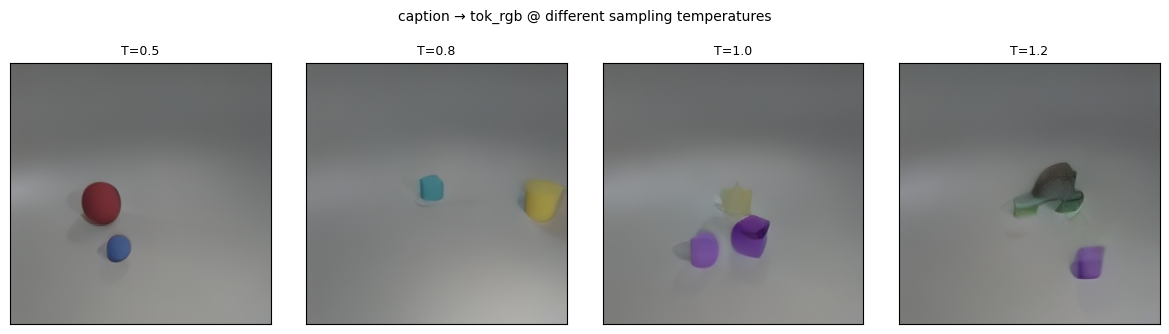

In [16]:
caption = "A small purple metal sphere and a medium brown rubber cube."
chunks = [chunk_text("caption", caption)]

temperatures = [0.5, 0.8, 1.0, 1.2]
fig, axes = plt.subplots(1, len(temperatures), figsize=(3 * len(temperatures), 3.2))
for ax, t in zip(axes, temperatures):
    out = generate(chunks, target_modality="tok_rgb@256", do_sample=True, temperature=t, seed=0)
    show_image(out, "tok_rgb@256", ax=ax, title=f"T={t}")
plt.suptitle(f"caption → tok_rgb @ different sampling temperatures", fontsize=10, y=1.03)
plt.tight_layout()
plt.show()

## 5. Customising experiments

The `chunks` / `generate(...)` API is intentionally minimal:

| You want                              | Build                                                                                              | Call                                                          |
|---------------------------------------|----------------------------------------------------------------------------------------------------|---------------------------------------------------------------|
| unconditional X                        | `[]`                                                                                               | `generate([], target_modality="X")`                           |
| text → X                               | `[chunk_text("caption", "...")]`                                                                   | `generate(chunks, target_modality="X")`                       |
| image → text                           | `[chunk_tokens("tok_rgb@256", path_or_array)]`                                                      | `generate(chunks, target_modality="caption", do_sample=True)` |
| multi-input → X                        | `[chunk_text(...), chunk_tokens(...), ...]`                                                        | `generate(chunks, target_modality="X")`                       |
| prefix completion of modality M       | `[chunk_tokens("M", arr, prefix_len=N)]`                                                            | `generate(chunks, continue_modality="M")`                     |
| custom modality order (multi-input)    | reorder the list — training used random order, so any permutation is in-distribution               | same as above                                                 |

A few things worth knowing:

- `chunk_text` truncates to `text_max_length=64` GPT-2 tokens (the same setting the dataset used at training time). Long captions silently lose their tail.
- `chunk_tokens` accepts either a `.npy` path *or* a numpy array. Pass the array form if you already loaded / modified the tokens (e.g. for inpainting masks or tokens you generated yourself in a previous cell).
- `tok_depth@256` and `tok_normal@256` use the same Cosmos VQ codebook layout as RGB, so `decode_image_tokens` works on all three. They just look different (depth ≈ greyscale, normals ≈ RGB-coded surface orientations) because the model emits codebook indices that the same Cosmos decoder maps into those visual styles.
- `scene_desc` is in the vocab but **was not in `active_modalities` for this checkpoint**, so quality there will be poor — caption is the trained text channel.
- Total prompt + new tokens must fit in `max_position_embeddings=1024`. With three image chunks (~258 each) you're already at ~774 tokens, so don't try to chain all four modalities as input.

A couple of follow-on experiments you can drop into a new cell:

```python
# Cycle consistency: caption -> rgb -> caption' . Does caption' agree with caption?
gen_rgb     = generate([chunk_text("caption", ref_captions[AUG_IDX])],
                       target_modality="tok_rgb@256", seed=0)
gen_caption = generate([chunk_tokens("tok_rgb@256", _strip_specials(gen_rgb, MODALITIES["tok_rgb@256"]))],
                       target_modality="caption", do_sample=True, temperature=0.7, seed=0)
show_text(gen_caption, "caption")
```

```python
# Sweep over multiple test images for a given direction
for sample_id in ["00001", "00002", "00003"]:
    rgb = np.load(DATA_TEST / "tok_rgb@256" / f"{sample_id}.npy")[AUG_IDX]
    out = generate([chunk_tokens("tok_rgb@256", rgb)],
                   target_modality="tok_depth@256", seed=0)
    fig, axes = plt.subplots(1, 2, figsize=(6, 3))
    show_image(rgb, "tok_rgb@256",   ax=axes[0], title=f"{sample_id} rgb")
    show_image(out, "tok_depth@256", ax=axes[1], title=f"{sample_id} depth")
    plt.show()
```

## 6. Router behaviour across modalities

So far we've used the router as a black box. With this checkpoint the architecture is:

- 29 transformer layers = `[first_layer] + [9 MoR-wrapped middle blocks × 3 recursions] + [last_layer]`
- Each of the 9 MoR-wrapped blocks owns its **own** MLP router that picks, per token, an expert index `k ∈ {0, 1, 2}` (= recursion depth `1`, `2` or `3`).
- A token assigned to expert `k` participates in passes `0…k` and exits, so `exit_depth = k + 1`.

Total per-token compute across the 9 MoR layers therefore lives in `[9, 27]`. We collect those decisions with forward hooks and slice the result by modality (using the BO/EO markers in the input) to study how the router spends its budget.

### Helpers — collect routing + segment by modality

In [18]:
NUM_RECURSION = cfg.recursive.num_recursion
_BO_TO_MOD = {info.bo_id: name for name, info in MODALITIES.items()}
_EO_IDS = {info.eo_id for info in MODALITIES.values()}


def segment_by_modality(input_ids: torch.Tensor) -> list[tuple[int, int, str]]:
    """Walk the sequence and return (body_start, body_end_exclusive, modality_name) triples.
    Only body tokens (between <BO> and <EO>) are returned; specials are excluded.
    """
    if input_ids.dim() > 1:
        input_ids = input_ids[0]
    segs, cur_start, cur_mod = [], None, None
    for i, t in enumerate(input_ids.tolist()):
        if t in _BO_TO_MOD:
            cur_start, cur_mod = i + 1, _BO_TO_MOD[t]
        elif t in _EO_IDS and cur_mod is not None:
            segs.append((cur_start, i, cur_mod))
            cur_start, cur_mod = None, None
    if cur_mod is not None:  # open chunk at end (e.g. prefix completion)
        segs.append((cur_start, int(input_ids.shape[0]), cur_mod))
    return segs


def collect_routing(input_ids: torch.Tensor) -> tuple[torch.Tensor, list]:
    """One no-cache forward pass with hooks on every MoR layer.

    Returns:
      depth   : LongTensor of shape (num_mor_layers, T) with values in [1, num_recursion],
                where depth[l, t] is the exit-depth of token t at MoR layer l.
      segments: list of (body_start, body_end_exclusive, modality_name).
    """
    captured: list[torch.Tensor] = []

    def hook(_m, _i, output):
        tei = getattr(output, "token_expert_indices", None)
        if tei is not None:
            captured.append(tei.detach().cpu())

    handles = [m.register_forward_hook(hook) for m in model.modules() if getattr(m, "mor", False)]
    try:
        if input_ids.dim() == 1:
            input_ids = input_ids.unsqueeze(0)
        with torch.no_grad():
            model(input_ids=input_ids.to(DEVICE), use_cache=False)
    finally:
        for h in handles:
            h.remove()
    if not captured:
        raise RuntimeError("No MoR layers fired — is mor.enable=true on this model?")
    depth = torch.stack([t[0] for t in captured], dim=0).long() + 1  # (L, T) in [1, Nr]
    return depth, segment_by_modality(input_ids)


print(f"num_recursion = {NUM_RECURSION}")
print(f"BO ids: {sorted(_BO_TO_MOD)}")
print(f"EO ids: {sorted(_EO_IDS)}")

num_recursion = 3
BO ids: [242260, 242262, 242264, 242266, 242268]
EO ids: [242261, 242263, 242265, 242267, 242269]


### G — Compute budget per modality

Build one sequence containing the **ground-truth tokens for all four modalities** (`caption + rgb + depth + normal`, ~770 tokens total — well under the 1024 limit), then look at:

- *Left*: per-MoR-layer average exit depth, one line per modality. If a line stays close to `num_recursion=3` the router consistently asks for max compute at that depth.
- *Middle*: a single bar per modality of the layer-averaged depth — the "compute fingerprint" of the modality.
- *Right*: total per-token compute across all 9 MoR layers, distributed across `[9, 27]`. A peaked distribution = uniform routing; a fat-tailed one = the router is being selective.

sequence length: 812, MoR layers captured: 1
  caption            body=[   1:  37]  (36 tokens)
  tok_rgb@256        body=[  39: 295]  (256 tokens)
  tok_depth@256      body=[ 297: 553]  (256 tokens)
  tok_normal@256     body=[ 555: 811]  (256 tokens)


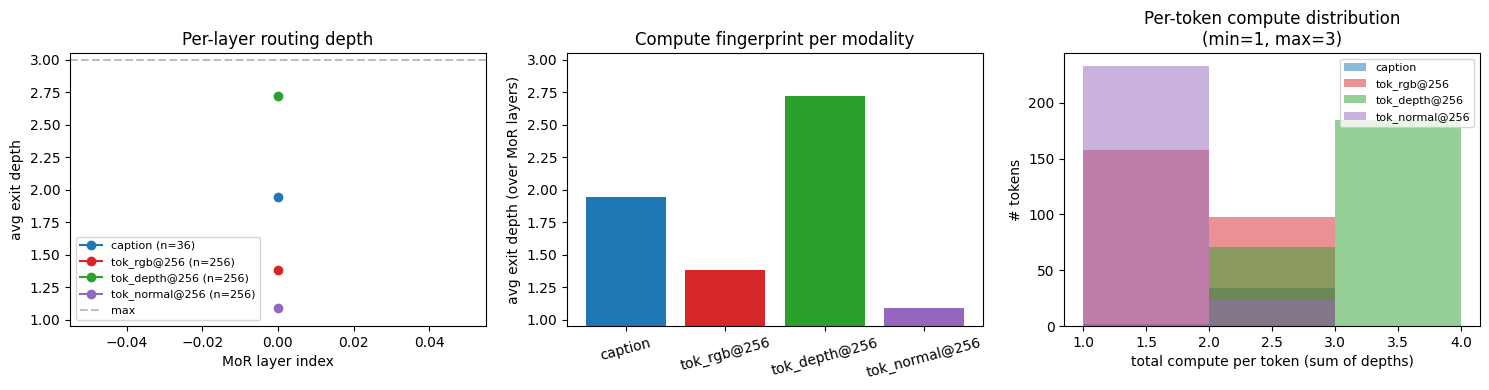

In [20]:
chunks_all = [
    chunk_text("caption", ref_captions[AUG_IDX]),
    chunk_tokens("tok_rgb@256", ref_rgb),
    chunk_tokens("tok_depth@256", ref_depth),
    chunk_tokens("tok_normal@256", ref_normal),
]
seq = torch.cat(chunks_all)
depth, segs = collect_routing(seq)
num_layers, T = depth.shape
print(f"sequence length: {T}, MoR layers captured: {num_layers}")
for s, e, m in segs:
    print(f"  {m:18s} body=[{s:4d}:{e:4d}]  ({e - s} tokens)")

palette = {
    "caption": "#1f77b4",
    "tok_rgb@256": "#d62728",
    "tok_depth@256": "#2ca02c",
    "tok_normal@256": "#9467bd",
}

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# 1) per-layer line plot
for s, e, m in segs:
    per_layer = depth[:, s:e].float().mean(dim=1).numpy()
    axes[0].plot(
        range(num_layers), per_layer, marker="o", label=f"{m} (n={e - s})", color=palette.get(m)
    )
axes[0].set_xlabel("MoR layer index")
axes[0].set_ylabel("avg exit depth")
axes[0].set_ylim(0.95, NUM_RECURSION + 0.05)
axes[0].axhline(NUM_RECURSION, ls="--", c="grey", alpha=0.5, label="max")
axes[0].set_title("Per-layer routing depth")
axes[0].legend(fontsize=8)

# 2) overall avg per modality
overall = [(m, depth[:, s:e].float().mean().item()) for s, e, m in segs]
axes[1].bar(
    [m for m, _ in overall], [v for _, v in overall], color=[palette.get(m) for m, _ in overall]
)
axes[1].set_ylim(0.95, NUM_RECURSION + 0.05)
axes[1].set_ylabel("avg exit depth (over MoR layers)")
axes[1].set_title("Compute fingerprint per modality")
axes[1].tick_params(axis="x", rotation=15)

# 3) histogram of total per-token compute (sum over layers)
total_compute_per_tok = depth.sum(dim=0)  # (T,)
for s, e, m in segs:
    axes[2].hist(
        total_compute_per_tok[s:e].numpy(),
        bins=range(num_layers, num_layers * NUM_RECURSION + 2),
        alpha=0.5,
        label=m,
        color=palette.get(m),
    )
axes[2].set_xlabel("total compute per token (sum of depths)")
axes[2].set_ylabel("# tokens")
axes[2].set_title(
    f"Per-token compute distribution\n(min={num_layers}, max={num_layers * NUM_RECURSION})"
)
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.show()

### H — Spatial routing maps for the three image modalities

Reshape the per-token avg depth into a 16×16 grid so we can see *where* compute concentrates inside an image. We also overlay the heatmap on the decoded RGB ground truth — bright patches = the router consistently asks for more passes there.

/tmp/ipykernel_599619/79043958.py:26: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("viridis", NUM_RECURSION + 1)


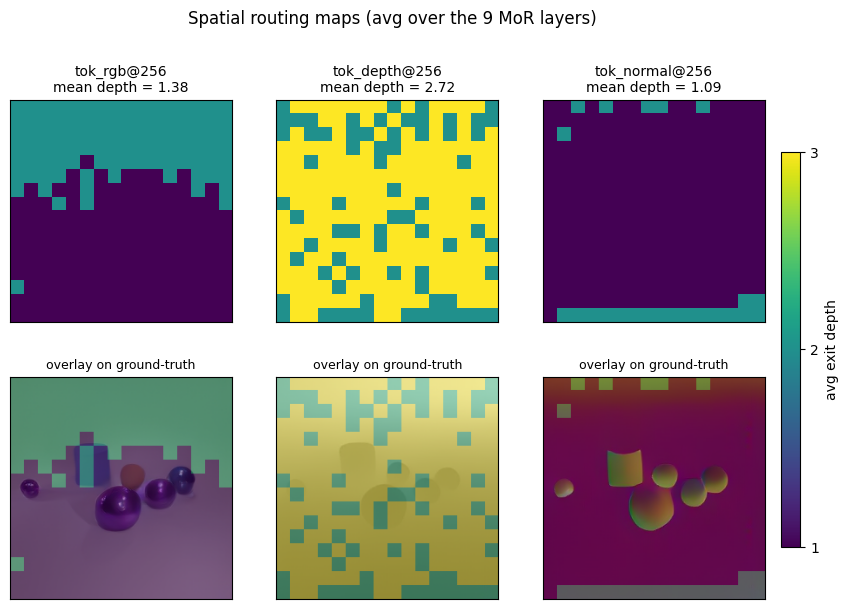

In [22]:
image_mods = ["tok_rgb@256", "tok_depth@256", "tok_normal@256"]
ref_arrays = {"tok_rgb@256": ref_rgb, "tok_depth@256": ref_depth, "tok_normal@256": ref_normal}
seg_lookup = {m: (s, e) for s, e, m in segs}

fig, axes = plt.subplots(2, len(image_mods), figsize=(3.4 * len(image_mods), 6.6))
for col, mod in enumerate(image_mods):
    s, e = seg_lookup[mod]
    if e - s != PATCH_GRID * PATCH_GRID:
        axes[0, col].set_title(f"{mod} ({e - s} tokens, expected {PATCH_GRID**2})")
        for r in range(2):
            axes[r, col].axis("off")
        continue
    grid = depth[:, s:e].float().mean(dim=0).reshape(PATCH_GRID, PATCH_GRID).numpy()

    im = axes[0, col].imshow(
        grid, cmap="viridis", vmin=1, vmax=NUM_RECURSION, interpolation="nearest"
    )
    axes[0, col].set_title(f"{mod}\nmean depth = {grid.mean():.2f}", fontsize=10)
    axes[0, col].set_xticks([])
    axes[0, col].set_yticks([])

    img = decode_image_tokens(ref_arrays[mod])
    if img is not None:
        from matplotlib import cm

        cmap = cm.get_cmap("viridis", NUM_RECURSION + 1)
        norm = (grid - 1.0) / max(NUM_RECURSION - 1, 1)  # in [0, 1]
        heat = (cmap(norm) * 255.0).astype(np.uint8)[..., :3]
        H, W = img.shape[:2]
        from PIL import Image as PILImage

        heat_full = np.asarray(PILImage.fromarray(heat).resize((W, H), PILImage.NEAREST))
        blend = (0.55 * img.astype(np.float32) + 0.45 * heat_full).clip(0, 255).astype(np.uint8)
        axes[1, col].imshow(blend)
        axes[1, col].set_title("overlay on ground-truth", fontsize=9)
    else:
        axes[1, col].axis("off")
    axes[1, col].set_xticks([])
    axes[1, col].set_yticks([])

cbar = fig.colorbar(
    im, ax=axes, orientation="vertical", fraction=0.025, pad=0.02, ticks=range(1, NUM_RECURSION + 1)
)
cbar.set_label("avg exit depth")
plt.suptitle("Spatial routing maps (avg over the 9 MoR layers)", y=1.01)
plt.show()

### I — Effect of conditioning context on target-modality routing

If extra context makes prediction easier, the router should be able to use shallower recursion on the target tokens. We fix the target to **depth** and feed the same ground-truth depth tokens with four different context configurations:

| Context              | Prompt structure                                            |
|----------------------|-------------------------------------------------------------|
| `none`               | `<BO_depth> ref_depth <EO_depth>`                           |
| `caption`            | `<BO_caption> caption <EO_caption>` + the depth chunk       |
| `rgb`                | `<BO_rgb> ref_rgb <EO_rgb>` + the depth chunk               |
| `caption + rgb`      | both context chunks + the depth chunk                       |

We measure the average exit depth on the **depth body tokens only** (256 tokens per run) and the per-MoR-layer profile for each context.

  none            prompt_len= 258  target slice=[1:257]  avg_depth=2.672
  caption         prompt_len= 296  target slice=[39:295]  avg_depth=2.699
  rgb             prompt_len= 516  target slice=[259:515]  avg_depth=2.688
  caption + rgb   prompt_len= 554  target slice=[297:553]  avg_depth=2.738


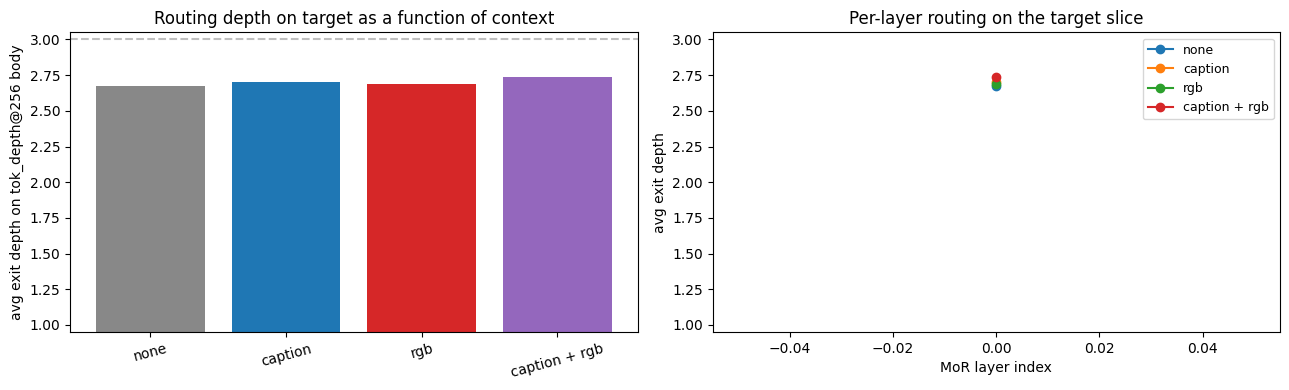


Delta vs. 'none' context (negative = easier prediction → shallower routing):
  none            Δ = +0.000
  caption         Δ = +0.027
  rgb             Δ = +0.016
  caption + rgb   Δ = +0.066


In [25]:
TARGET_MOD = "tok_depth@256"
target_chunk = chunk_tokens(TARGET_MOD, ref_depth)  # closed; the body is the GT depth tokens

contexts = {
    "none": [],
    "caption": [chunk_text("caption", ref_captions[AUG_IDX])],
    "rgb": [chunk_tokens("tok_rgb@256", ref_rgb)],
    "caption + rgb": [
        chunk_text("caption", ref_captions[AUG_IDX]),
        chunk_tokens("tok_rgb@256", ref_rgb),
    ],
}

results = {}  # name -> (mean_depth, per_layer_means [num_layers,])
for name, ctx in contexts.items():
    seq_ctx = torch.cat(ctx + [target_chunk])
    d, segs_ctx = collect_routing(seq_ctx)
    s, e = next((s, e) for s, e, m in segs_ctx if m == TARGET_MOD)
    body = d[:, s:e].float()  # (L, 256)
    results[name] = (body.mean().item(), body.mean(dim=1).numpy())
    print(
        f"  {name:14s}  prompt_len={len(seq_ctx):4d}  target slice=[{s}:{e}]  avg_depth={results[name][0]:.3f}"
    )

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].bar(
    results.keys(),
    [v[0] for v in results.values()],
    color=["#888", "#1f77b4", "#d62728", "#9467bd"],
)
axes[0].set_ylim(0.95, NUM_RECURSION + 0.05)
axes[0].axhline(NUM_RECURSION, ls="--", c="grey", alpha=0.5)
axes[0].set_ylabel(f"avg exit depth on {TARGET_MOD} body")
axes[0].set_title("Routing depth on target as a function of context")
axes[0].tick_params(axis="x", rotation=15)

for name, (_, per_layer) in results.items():
    axes[1].plot(range(len(per_layer)), per_layer, marker="o", label=name)
axes[1].set_ylim(0.95, NUM_RECURSION + 0.05)
axes[1].set_xlabel("MoR layer index")
axes[1].set_ylabel("avg exit depth")
axes[1].set_title("Per-layer routing on the target slice")
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()
print("\nDelta vs. 'none' context (negative = easier prediction → shallower routing):")
base = results["none"][0]
for name, (avg, _) in results.items():
    print(f"  {name:14s}  Δ = {avg - base:+.3f}")

### J — Specials vs body, BO vs EO vs PAD

The router fires on **every** position in the input, including the BO / EO markers between modalities. These tokens are rare (~1% of the sequence) and structural — do they get routed differently from body tokens? We classify each position into:

- `body[modality]` — between `<BO_mod>` and `<EO_mod>`
- `BO_mod`, `EO_mod` — the markers themselves
- `PAD` — never present here, but listed for completeness

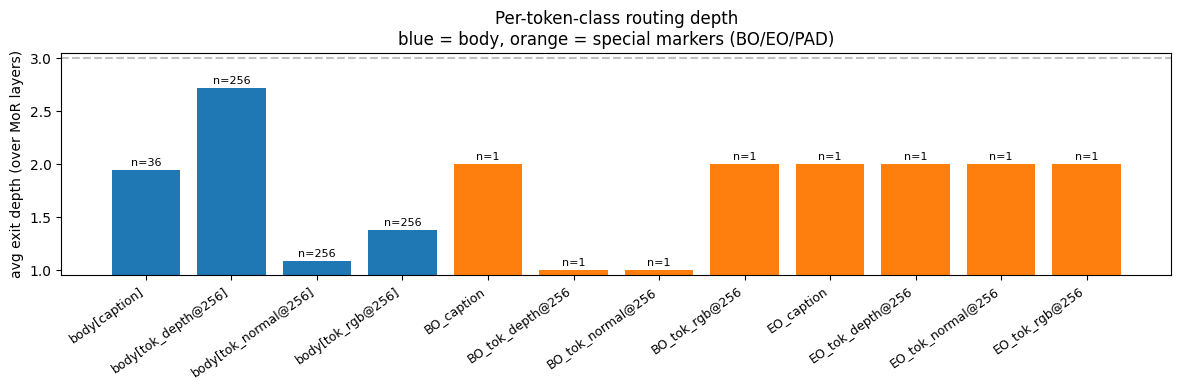

In [24]:
# Reuse the earlier 4-modality `seq` / `depth` / `segs` from experiment G.
# Per-token average depth across all MoR layers.
avg_depth_per_token = depth.float().mean(dim=0).numpy()  # (T,)
seq_np = seq.numpy()

categories: dict[str, list[int]] = {}


def _push(cat: str, idx: int):
    categories.setdefault(cat, []).append(idx)


for i, t in enumerate(seq_np.tolist()):
    if t in _BO_TO_MOD:
        _push(f"BO_{_BO_TO_MOD[t]}", i)
    elif t in _EO_IDS:
        eo_to_mod = {info.eo_id: name for name, info in MODALITIES.items()}
        _push(f"EO_{eo_to_mod[t]}", i)
    elif t == PAD_ID:
        _push("PAD", i)

for s, e, m in segs:
    categories.setdefault(f"body[{m}]", []).extend(range(s, e))


# Order categories nicely: bodies first (largest), then BO/EO grouped by modality
def _sort_key(name):
    if name.startswith("body["):
        return (0, name)
    if name.startswith("BO_"):
        return (1, name[3:])
    if name.startswith("EO_"):
        return (2, name[3:])
    return (3, name)


ordered = sorted(categories.keys(), key=_sort_key)
means = [np.mean(avg_depth_per_token[categories[c]]) for c in ordered]
counts = [len(categories[c]) for c in ordered]

fig, ax = plt.subplots(figsize=(12, 4))
xs = np.arange(len(ordered))
colors = ["#1f77b4" if c.startswith("body[") else "#ff7f0e" for c in ordered]
bars = ax.bar(xs, means, color=colors)
ax.set_xticks(xs)
ax.set_xticklabels(ordered, rotation=35, ha="right", fontsize=9)
ax.set_ylim(0.95, NUM_RECURSION + 0.05)
ax.axhline(NUM_RECURSION, ls="--", c="grey", alpha=0.5)
ax.set_ylabel("avg exit depth (over MoR layers)")
ax.set_title("Per-token-class routing depth\nblue = body, orange = special markers (BO/EO/PAD)")
for bar, n in zip(bars, counts):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.02,
        f"n={n}",
        ha="center",
        va="bottom",
        fontsize=8,
    )
plt.tight_layout()
plt.show()

### Suggestions for further router experiments

A few directions you can drop into a fresh cell once you've gotten a feel for the helpers above:

```python
# Stability: same modality, multiple samples — is the spatial heatmap consistent
# across CLEVR scenes, or does it follow object positions?
sample_ids = ["00000", "00001", "00002", "00003"]
maps = []
for sid in sample_ids:
    rgb = np.load(DATA_TEST / "tok_rgb@256" / f"{sid}.npy")[AUG_IDX]
    seq_i = chunk_tokens("tok_rgb@256", rgb)
    d, segs_i = collect_routing(seq_i)
    s, e = next((s, e) for s, e, m in segs_i if m == "tok_rgb@256")
    maps.append(d[:, s:e].float().mean(dim=0).reshape(PATCH_GRID, PATCH_GRID).numpy())
mean_map = np.mean(maps, axis=0)
plt.imshow(mean_map, cmap="viridis", vmin=1, vmax=NUM_RECURSION); plt.colorbar()
plt.title(f"avg routing map across {len(sample_ids)} RGB images"); plt.show()
```

```python
# Order sensitivity: training was modality_order=random — does the model really
# treat (caption, rgb) and (rgb, caption) symmetrically as inputs to depth prediction?
for ordering in [["caption", "tok_rgb@256"], ["tok_rgb@256", "caption"]]:
    chunks_o = [chunk_text(m, ref_captions[AUG_IDX]) if m == "caption"
                else chunk_tokens(m, ref_rgb)
                for m in ordering]
    d, segs_o = collect_routing(torch.cat(chunks_o + [target_chunk]))
    s, e = next((s, e) for s, e, m in segs_o if m == TARGET_MOD)
    print(f"  order {ordering} -> avg depth on depth body = {d[:, s:e].float().mean().item():.3f}")
```

```python
# Bridge to the next research question: layer-by-layer expert distribution, not just mean.
# This shows whether routing is "binary" (most tokens take 1 or 3, few take 2) or graded.
for li in range(num_layers):
    counts = torch.bincount(depth[li].view(-1) - 1, minlength=NUM_RECURSION).numpy()
    print(f"layer {li}: " + "  ".join(f"d={k+1}:{counts[k]/counts.sum():.1%}"
                                      for k in range(NUM_RECURSION)))
```

Things to keep in mind when interpreting these plots:

- The router was trained with **balancing loss (coeff=0.1)** and **z_loss (0.001)**, so we should expect the per-layer marginal over `{1, 2, 3}` to be roughly uniform in aggregate. Any deviation **per modality** is the real signal — that's the router actually saying "this kind of input needs different compute".
- All measurements above use **ground-truth tokens**. Routing during *generation* is similar but not identical, because the model is conditioning on its own mistakes. To compare, you can run `collect_routing` on the output of `generate(...)` and look at the routing on the *generated* slice.
- Total compute per token is bounded by `[num_mor_layers, num_mor_layers × num_recursion]` = `[9, 27]` for this checkpoint. The non-MoR first/last layers always run, so they don't appear in the router stats.